In [1]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200


import math
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from tqdm import tqdm

c:\Users\thanh\miniconda3\envs\deepl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

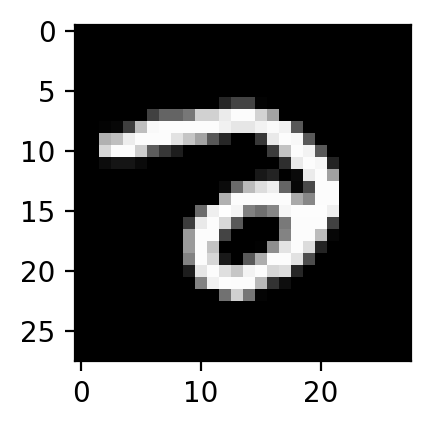

x_shape: torch.Size([128, 1, 28, 28])
min: 0.0 max: 1.0
mean: 0.13336342573165894, var: 0.09620027244091034


In [3]:
BATCH_SIZE = 128

data = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.ToTensor(),
    download=True),
    batch_size=BATCH_SIZE,
    shuffle=True)

x, y = next(iter(data))     # Shape: (batch_size, 1, 28, 28)
x_sample = torch.permute(x[0], (2, 1, 0))

ax = plt.subplot(211)
ax.imshow(x_sample, cmap="gray")
plt.show()

print(f"x_shape: {x.shape}")
print(f"min: {torch.min(x_sample)} max: {torch.max(x_sample)}")
print(f"mean: {torch.mean(x)}, var: {torch.var(x)}")

### Diffusion Model

In [4]:
# -- Essential Convolution blocks
class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=3,
                              stride=2,
                              padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(in_channels=in_channels,
                                       out_channels=out_channels,
                                       kernel_size=4,
                                       stride=2,
                                       padding=1)
    
    def forward(self, x):
        return self.conv(x)


class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels, residual=False, n_groups=1):
        super().__init__()
        self.residual = residual

        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, 
                      kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=n_groups, num_channels=out_channels),
            nn.Mish()
        )
    
    def forward(self, x):
        if self.residual:
            return F.mish(x + self.block(x))
        else:
            return self.block(x)


# -- U-net blocks based on https://arxiv.org/pdf/1505.04597
class DoubleConv(nn.Module):
    """
    Double Convolution block with slight activation func deviation
    (convolution => [Norm] => Mish) * 2
    """
    def __init__(self, in_channels, out_channels, mid_channels=None, n_groups=1):
        super().__init__()

        # Determine convolutional channels for mid
        if not mid_channels:
            mid_channels = out_channels

        # Double convolution block
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=mid_channels, 
                      kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=n_groups, num_channels=mid_channels),
            nn.Mish(),      # Deviation from Relu
            nn.Conv2d(in_channels=mid_channels, out_channels=out_channels, 
                      kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=n_groups, num_channels=out_channels),
            nn.Mish(),      # Deviation from Relu
        )

    def forward(self, x):
        return self.block(x)
    

class DownMaxPoolConv(nn.Module):
    """
    Downscaling with maxpool then double conv
    """
    def __init__(self, in_channels, out_channels, mid_channels=None, n_groups=1,
                 time_emb_dim=256):
        super().__init__()

        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels=in_channels, out_channels=out_channels,
                       mid_channels=mid_channels, n_groups=n_groups)
        )

        # Time-embedding layer
        self.time_emb_layer = nn.Sequential(
            nn.Mish(),
            nn.Linear(
                time_emb_dim,
                out_channels
            ),
        )
    
    def forward(self, x, t=None):
        if t is not None:
            x = self.maxpool_conv(x)
            # Broadcast time embedding to (B, C, H, W)
            # t = t[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
            t = self.time_emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
            return x + t
        else:
            return self.maxpool_conv(x)


class UpConv(nn.Module):
    """
    Upscaling with conv transpose then double conv
    """
    def __init__(self, in_channels, out_channels, mid_channels=None, n_groups=1,
                 time_emb_dim=256):
        super().__init__()
        # Upsample with conv transpose but have number of channels halve
        self.up_conv = nn.Sequential(
            nn.ConvTranspose2d(in_channels=in_channels, out_channels=in_channels // 2,
                               kernel_size=2, stride=2),
            DoubleConv(in_channels=in_channels // 2, out_channels=out_channels,
                       mid_channels=mid_channels, n_groups=n_groups)
        )

        # Individual Up Sample blocks + Double conv
        self.up = nn.ConvTranspose2d(in_channels=in_channels, out_channels=in_channels // 2,
                                     kernel_size=4, stride=2, padding=1)
        self.double_conv = DoubleConv(in_channels=in_channels, out_channels=out_channels,
                                      mid_channels=mid_channels, n_groups=n_groups)
        
        # Time-embedding layer
        self.time_emb_layer = nn.Sequential(
            nn.Mish(),
            nn.Linear(
                time_emb_dim,
                out_channels
            ),
        )
    
    def forward(self, x1, x2=None, t=None):
        if x2 is not None:
            # -- Deal with residual
            # Input is of (Batch size, channels, height, width)
            # TODO: Deal with padding

            # Upscale first
            x1 = self.up(x1)

            # Concat along channels axis
            x = torch.cat([x2, x1], dim=1)

            x = self.double_conv(x)
        else:
            # Otherwise up scale and double conv
            x = self.up_conv(x1)

        # Deal with time-embedding
        if t is not None:
            # t = t[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
            t = self.time_emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
            return x + t
        else:
            return x


# -- Position embeddings
class SinusoidalPosEmb(nn.Module):
    # TODO: Investigate
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


# -- U-Net based on https://arxiv.org/pdf/1505.04597
class UNetClassic(nn.Module):
    """
    U-Net classic 
    Based on architecture specified in https://arxiv.org/pdf/1505.04597 (fig1)
    Implementation details: https://github.com/milesial/Pytorch-UNet/blob/master/unet/unet_model.py
    """
    def __init__(self, c_in=1, c_out=1, time_dim=256, device="cuda"):
        super().__init__()

        self.device = device
        self.time_dim = time_dim    # Time diffusion step embedding dimension

        # -- Diffusion step encoder
        # Time embeddings
        diffusion_step_encoder = nn.Sequential(
            SinusoidalPosEmb(dim=self.time_dim),
            # nn.Linear(self.time_dim, self.time_dim*4),
            # nn.Mish(),
            # nn.Linear(self.time_dim*4, self.time_dim),
        )
        self.diffusion_step_encoder = diffusion_step_encoder

        # -- U-net blocks
        self.inc = DoubleConv(in_channels=c_in, out_channels=64)
        self.down1 = DownMaxPoolConv(in_channels=64, out_channels=128)      # (H,W) = (14,14)
        self.down2 = DownMaxPoolConv(in_channels=128, out_channels=256)     # (H,W) = (7,7)
        
        # self.bot = DoubleConv(in_channels=256, out_channels=256)

        self.up1 = UpConv(in_channels=256, out_channels=128)
        self.up2 = UpConv(in_channels=128, out_channels=64)
        self.outc = nn.Conv2d(in_channels=64, out_channels=c_out, 
                              kernel_size=3, padding=1)
        
    # def pos_encoding(self, t, channels):
    #     inv_freq = 1.0 / (
    #         10000
    #         ** (torch.arange(0, channels, 2, device=self.device).float() / channels)
    #     )
    #     pos_enc_a = torch.sin(t.repeat(1, channels // 2) * inv_freq)
    #     pos_enc_b = torch.cos(t.repeat(1, channels // 2) * inv_freq)
    #     pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
    #     return pos_enc

    def forward(self, sample, timestep):
        # -- Time Embeddings
        # Get timestep embeddings
        timesteps = timestep
        if not torch.is_tensor(timesteps):
            # TODO: this requires sync between CPU and GPU. So try to pass timesteps as tensors if you can
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(sample.device)
        # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
        timesteps = timesteps.expand(sample.shape[0])
        t_emb = self.diffusion_step_encoder(timesteps)

        # -- Sample Forward pass
        x1 = self.inc(sample)
        # x2 = self.down1(x1)
        # x3 = self.down2(x2)

        x2 = self.down1(x1, t_emb)
        x3 = self.down2(x2, t_emb)

        # x = self.bot(x3)

        x = self.up1(x3, x2, t_emb)
        x = self.up2(x, x1, t_emb)
        logits = self.outc(x)
        return logits


class UNet(nn.Module):
    def __init__(self, c_in=1, c_out=1, time_dim=256, device="cuda"):
        super().__init__()

        self.device = device
        self.time_dim = time_dim    # Time diffusion step embedding dimension

        # -- Diffusion step encoder
        # Time embeddings
        diffusion_step_encoder = nn.Sequential(
            SinusoidalPosEmb(dim=self.time_dim),
            nn.Linear(self.time_dim, self.time_dim*4),
            nn.Mish(),
            nn.Linear(self.time_dim*4, self.time_dim),
        )
        self.diffusion_step_encoder = diffusion_step_encoder

        # -- Unet modules        
        self.inc = Conv2dBlock(c_in, 64)
        self.down1 = Downsample(64, 128)
        self.conv1 = Conv2dBlock(128, 128)
        self.down2 = Downsample(128, 256)

        self.bot1 = Conv2dBlock(256, 256)
        self.bot2 = Conv2dBlock(256, 256)

        self.up1 = Upsample(256, 128)
        self.conv2 = Conv2dBlock(128, 128)
        self.up2 = Upsample(128, 64)
        self.outc = Conv2dBlock(64, c_out)
    
    def forward(self, sample, timestep):
        # -- Time Embeddings
        # Get timestep embeddings
        timesteps = timestep
        if not torch.is_tensor(timesteps):
            # TODO: this requires sync between CPU and GPU. So try to pass timesteps as tensors if you can
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(sample.device)
        # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
        timesteps = timesteps.expand(sample.shape[0])

        time_step_embedding = self.diffusion_step_encoder(timesteps)
        print(f"time_step_embedding {time_step_embedding.shape}:\n{time_step_embedding}")

        # -- Sample Forward pass
        x = self.inc(sample)
        x = self.down1(x)
        x = self.conv1(x)
        x = self.down2(x)

        x = self.bot1(x)
        x = self.bot2(x)

        x = self.up1(x)
        x = self.conv2(x)
        x = self.up2(x)
        output = self.outc(x)
        
        return output

#### Conv Testing

In [5]:
# -- U-net (custom)

# -- Conv 2D Block
# torch.Size([128, 1, 28, 28])
x_test = torch.randn(128, 1, 28, 28)
conv2d_block = Conv2dBlock(in_channels=1, out_channels=64, residual=False)

# x = conv2d_block(x_test)
# print(f"x {x.shape}:\n{x}")

conv2d_out = conv2d_block(x_test)
print(f"conv2d_out shape: {conv2d_out.shape}")

# -- Downsample
print(f"\n--- Downsample Testing ---")
down1 = Downsample(in_channels=1, out_channels=64)
down2 = Downsample(in_channels=64, out_channels=128)
down3 = Downsample(in_channels=128, out_channels=256)

down_out1 = down1(x_test)
down_out2 = down2(down_out1)
down_out3 = down3(down_out2)

print(f"down_out1 shape: {down_out1.shape}")
print(f"down_out2 shape: {down_out2.shape}")
print(f"down_out3 shape: {down_out3.shape}")

# -- Upsample
print(f"\n--- Upsample Testing ---")
up1 = Upsample(in_channels=256, out_channels=128)
up2 = Upsample(in_channels=128, out_channels=64)
up3 = Upsample(in_channels=64, out_channels=1)

up_out1 = up1(down_out3)
up_out2 = up2(up_out1)
up_out3 = up3(up_out2)

print(f"up_out1 shape:{up_out1.shape}")
print(f"up_out2 shape:{up_out2.shape}")
print(f"up_out3 shape:{up_out3.shape}")

conv2d_out shape: torch.Size([128, 64, 28, 28])

--- Downsample Testing ---
down_out1 shape: torch.Size([128, 64, 14, 14])
down_out2 shape: torch.Size([128, 128, 7, 7])
down_out3 shape: torch.Size([128, 256, 4, 4])

--- Upsample Testing ---
up_out1 shape:torch.Size([128, 128, 8, 8])
up_out2 shape:torch.Size([128, 64, 16, 16])
up_out3 shape:torch.Size([128, 1, 32, 32])


In [6]:
# -- U-net (https://arxiv.org/pdf/1505.04597) block testing
# Test data
x_test = torch.randn(128, 1, 28, 28)

# -- Double Conv
print("--- Double Conv Testing ---")
double_conv = DoubleConv(in_channels=1, out_channels=64)
double_conv_out = double_conv(x_test)

print(f"double_conv_out shape: {double_conv_out.shape}")

# -- Downsample
print(f"\n--- Downsample Testing ---")
down1 = DownMaxPoolConv(in_channels=1, out_channels=64)
down2 = DownMaxPoolConv(in_channels=64, out_channels=128)
down3 = DownMaxPoolConv(in_channels=128, out_channels=256)

down_out1 = down1(x_test)
down_out2 = down2(down_out1)
down_out3 = down3(down_out2)    # Don't reduce down from (7x7) to (3x3) to retain original shape

print(f"down_out1 shape: {down_out1.shape}")
print(f"down_out2 shape: {down_out2.shape}")
print(f"down_out3 shape: {down_out3.shape}")

# -- Upsample
print(f"\n--- Upsample Testing ---")
up1 = UpConv(in_channels=128, out_channels=64)
up2 = UpConv(in_channels=64, out_channels=1)

up_out1 = up1(down_out2)        # Start from (7x7) downsampled version to get orig. shape of (28x28)
up_out2 = up2(up_out1)

print(f"up_out1 shape:{up_out1.shape}")
print(f"up_out2 shape:{up_out2.shape}")

--- Double Conv Testing ---
double_conv_out shape: torch.Size([128, 64, 28, 28])

--- Downsample Testing ---
down_out1 shape: torch.Size([128, 64, 14, 14])
down_out2 shape: torch.Size([128, 128, 7, 7])
down_out3 shape: torch.Size([128, 256, 3, 3])

--- Upsample Testing ---
up_out1 shape:torch.Size([128, 64, 14, 14])
up_out2 shape:torch.Size([128, 1, 28, 28])


### U-Net Testing

In [7]:
# sample data extraction
data = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.ToTensor(),
    download=True),
    batch_size=BATCH_SIZE,
    shuffle=True)
x, y = next(iter(data))     # Shape: (batch_size, 1, 28, 28)

x = x.to(device)
y = y.to(device)

# for this demo, we use DDPMScheduler with 100 diffusion iterations
num_diffusion_iters = 100
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_diffusion_iters,
    # the choise of beta schedule has big impact on performance
    # we found squared cosine works the best
    beta_schedule='squaredcos_cap_v2',
    # clip output to [-1,1] to improve stability
    clip_sample=True,
    # our network predicts noise (instead of denoised action)
    prediction_type='epsilon'
)

# sample a diffusion iteration for each data point
timesteps = torch.randint(
    0, noise_scheduler.config.num_train_timesteps,
    (BATCH_SIZE,), device=device
).to(device=device)

# Pass through U-net
# unet = UNet().to(device=device)
unet = UNetClassic().to(device=device)
output = unet(sample=x, timestep=timesteps)

print("--- Timesteps ---")
print(f"timesteps {timesteps.shape}:\n{timesteps}")

print("\n--- Output ---")
print(f"output {output.shape}:\n{output}")

--- Timesteps ---
timesteps torch.Size([128]):
tensor([41, 97, 91, 72, 53,  4,  3, 33, 42, 33, 90, 17, 98, 84, 78,  8, 64, 11,
        22, 91, 12, 57, 51, 75, 34, 37, 76,  2,  7, 39, 90, 35, 14, 47, 40, 66,
        72, 77, 54, 14, 26, 58, 31, 76, 48, 91,  5, 53, 68, 33, 65, 43,  7, 65,
         2, 62, 57, 99, 49, 75, 99, 57, 25, 29, 93, 62, 97, 82, 71, 89, 67, 32,
        88, 22, 65, 65, 94, 89, 20, 51, 47, 19,  3, 23, 53, 49,  5, 76, 63, 64,
        30, 23, 66, 72, 61, 83, 78, 84, 28, 59, 98, 64,  3, 79, 94, 29, 16,  2,
        99, 62, 11, 87, 41, 47, 72, 23, 92, 48, 70,  1, 33, 75, 34, 55, 95, 55,
        87, 93], device='cuda:0')

--- Output ---
output torch.Size([128, 1, 28, 28]):
tensor([[[[ 0.1574,  0.1417,  0.2100,  ...,  0.1311,  0.1669,  0.1055],
          [ 0.0926,  0.1733,  0.1859,  ...,  0.1948,  0.1748,  0.1804],
          [ 0.0611,  0.0977,  0.1863,  ...,  0.1105,  0.1372,  0.1388],
          ...,
          [ 0.1349,  0.0941,  0.2200,  ...,  0.1411,  0.1854,  0.1610],
   

### Training

In [8]:
# -- Params
BATCH_SIZE = 256
LEARNING_RATE = 1e-4
EPOCHS = 100

# -- Dataset 
train_dataloader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.ToTensor(),
    download=True),
    batch_size=BATCH_SIZE,
    shuffle=True)

# -- Architecture
# Noise scheduler
num_diffusion_iters = 100
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_diffusion_iters,
    # the choise of beta schedule has big impact on performance
    # we found squared cosine works the best
    beta_schedule='squaredcos_cap_v2',
    # clip output to [-1,1] to improve stability
    clip_sample=True,
    # our network predicts noise (instead of denoised action)
    prediction_type='epsilon'
)

# U-net
model = UNetClassic().to(device=device)
model.train()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)     # TODO: Investigate and replace with AdamW?
criterion = nn.MSELoss()


In [9]:
# -- Training
losses = []
for epoch in range(EPOCHS):  # Example: 10 epochs
    print(f"Epoch {epoch+1}/{EPOCHS}")
    epoch_loss = 0.0
    pbar = tqdm(train_dataloader)
    for i, (images, labels) in enumerate(pbar):
        images = images.to(device)

        # sample a diffusion iteration for each data point
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (images.shape[0],), device=device
        ).to(device=device)

        # sample noise to add to image
        noise = torch.randn(images.shape, device=device)

        # add noise to the clean images according to the noise magnitude at each diffusion iteration
        # (this is the forward diffusion process)
        noisy_image = noise_scheduler.add_noise(
            images, noise, timesteps)
        
        # predict noise
        predicted_noise = model(sample=noisy_image, timestep=timesteps)
        loss = criterion(predicted_noise, noise)

        # Optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.set_postfix(MSE=loss.item())
        epoch_loss += loss.item()

    epoch_loss /= len(train_dataloader)
    losses.append(epoch_loss)




Epoch 1/100


100%|██████████| 235/235 [00:24<00:00,  9.49it/s, MSE=0.0648]


Epoch 2/100


100%|██████████| 235/235 [00:24<00:00,  9.44it/s, MSE=0.0437]


Epoch 3/100


...

100%|██████████| 235/235 [00:48<00:00,  4.85it/s, MSE=0.0282]


Epoch 99/100


100%|██████████| 235/235 [00:40<00:00,  5.80it/s, MSE=0.0231]


Epoch 100/100


100%|██████████| 235/235 [00:41<00:00,  5.68it/s, MSE=0.0224]


Text(0.5, 1.0, 'Epoch Loss')

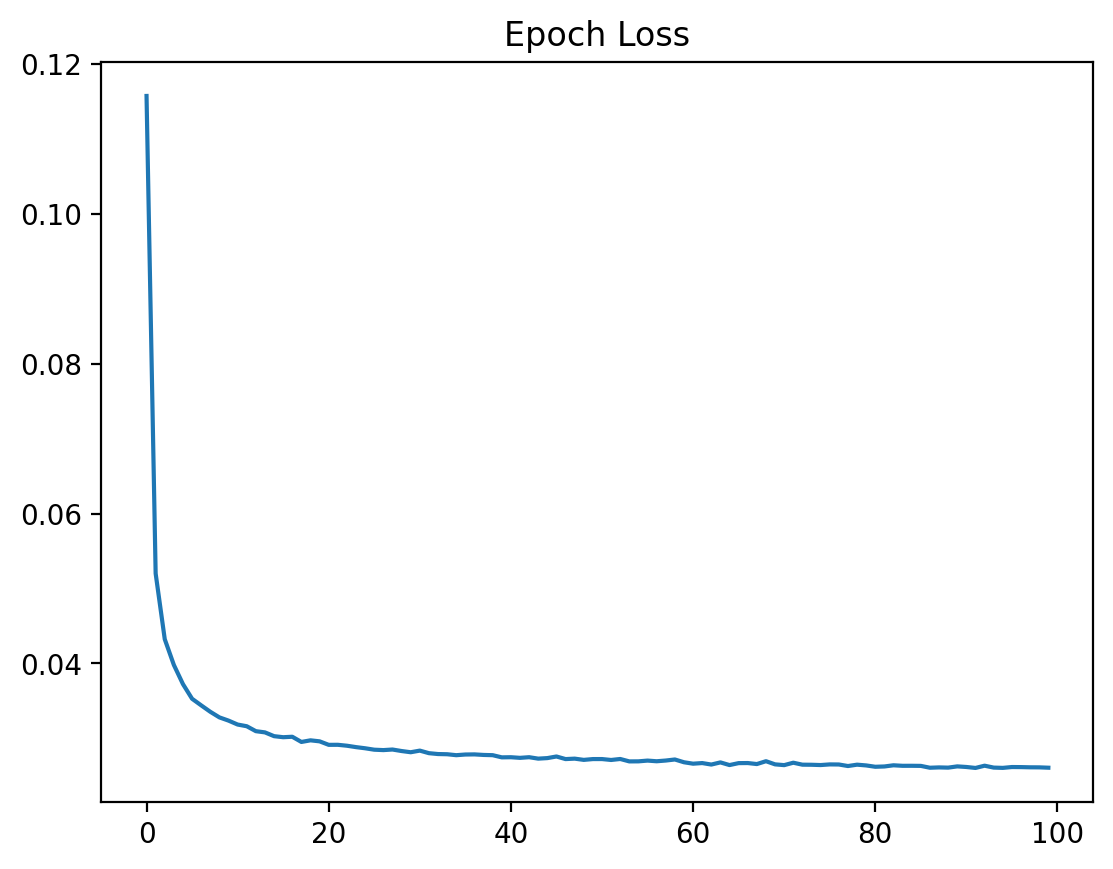

In [10]:
plt.plot(losses)
plt.title("Epoch Loss")

### Sampling Diffusion model

In [37]:
import time

# Initial noisy image
nimage = torch.randn((1, 1, 28, 28)).to(device)

# init scheduler
noise_scheduler.set_timesteps(num_diffusion_iters)

# run everything in inference mode
start_time = time.time()
model.eval()

for k in noise_scheduler.timesteps:
    # predict noise
    noise_pred = model(
        sample=nimage,
        timestep=k,
    )

    # inverse diffusion step (remove noise)
    nimage = noise_scheduler.step(
        model_output=noise_pred,
        timestep=k,
        sample=nimage
    ).prev_sample

print(f"[INFO]: Elasped time: {time.time() - start_time:.4f} seconds")

[INFO]: Elasped time: 0.6981 seconds


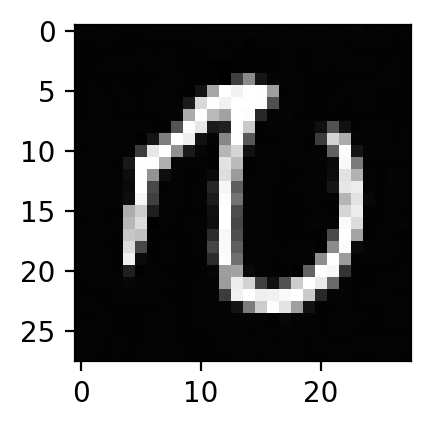

In [38]:
x_sample = torch.permute(nimage[0], (2, 1, 0)).detach().cpu().numpy()

ax = plt.subplot(211)
ax.imshow(x_sample, cmap="gray")
plt.show()